In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [56]:
import numpy as np
import pandas as pd
from collections import defaultdict

# Load data
ratings = pd.read_csv("/content/drive/MyDrive/ml-100k/u.data", sep="\t",
                      names=["user_id", "movie_id", "rating", "timestamp"])
movies = pd.read_csv("/content/drive/MyDrive/ml-100k/u.item", sep="|", encoding="latin-1",
                     names=["movie_id", "title", "release_date", "video_release_date", "IMDb_URL",
                            "unknown", "Action", "Adventure", "Animation", "Children's", "Comedy",
                            "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror",
                            "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"])


In [57]:
ratings['reward'] = np.where(ratings['rating'] >= 4, 1, -1)

movies['genres'] = movies.iloc[:, 5:].apply(lambda x: '|'.join(x.index[x==1]), axis=1)
genre_columns = movies.columns[5:-1]

In [83]:
# ------------------------------
# 1. Epsilon-Greedy Bandit
# ------------------------------
class EpsilonGreedyBandit:
    def __init__(self, epsilon=0.1):
        self.epsilon = epsilon
        self.movie_rewards = defaultdict(lambda: {'sum': 0, 'count': 0})
        self.movies = ratings['movie_id'].unique()

    def recommend(self, user_id=None):
        if np.random.random() < self.epsilon:
            return np.random.choice(self.movies)
        else:
            if not self.movie_rewards:
                return np.random.choice(self.movies)
            avg_rewards = {mid: data['sum']/data['count']
                          for mid, data in self.movie_rewards.items() if data['count'] > 0}
            if avg_rewards:
                return max(avg_rewards.items(), key=lambda x: x[1])[0]
            else:
                return np.random.choice(self.movies)

    def update(self, movie_id, reward):
        self.movie_rewards[movie_id]['sum'] += reward
        self.movie_rewards[movie_id]['count'] += 1


In [95]:
# ------------------------------
# 2. Q-Learning Recommender
# ------------------------------
class QLearningRecommender:
    def __init__(self, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = defaultdict(lambda: defaultdict(float))
        self.movies = ratings['movie_id'].unique()

    def get_state(self, user_id):
        user_ratings = ratings[ratings['user_id'] == user_id]
        if len(user_ratings) == 0:
            return 'new_user'
        user_movies = movies[movies['movie_id'].isin(user_ratings['movie_id'])]
        genre_counts = user_movies[genre_columns].sum()
        top_genres = genre_counts.nlargest(2).index.tolist()
        return '_'.join(top_genres) if len(top_genres) > 0 else 'new_user'

    def recommend(self, user_id):
        state = self.get_state(user_id)
        if np.random.random() < self.epsilon:
            return np.random.choice(self.movies)
        else:
            if state not in self.q_table or not self.q_table[state]:
                return np.random.choice(self.movies)
            return max(self.q_table[state].items(), key=lambda x: x[1])[0]

    def recommend_top_n_for_new_user(self, favorite_movie_ids, n=5):
        state = get_user_preference_from_favorites(favorite_movie_ids)

        if state not in self.q_table or len(self.q_table[state]) == 0:
            random_movies = np.random.choice(self.movies, size=n, replace=False)
            result = []
            for mid in random_movies:
                title = movies[movies["movie_id"] == mid]["title"].values[0]
                result.append((mid, title))
            return result

        sorted_movies = sorted(
            self.q_table[state].items(),
            key=lambda x: x[1],
            reverse=True
        )

        top_n_ids = [mid for mid, _ in sorted_movies[:n]]

        recommendations = []
        for mid in top_n_ids:
            title = movies[movies["movie_id"] == mid]["title"].values[0]
            recommendations.append((mid, title))

        return recommendations


    def update(self, user_id, movie_id, reward, next_user_id=None):
        state = self.get_state(user_id)
        next_state = self.get_state(next_user_id) if next_user_id else state
        old_value = self.q_table[state][movie_id]
        next_max = max(self.q_table[next_state].values()) if self.q_table[next_state] else 0
        new_value = old_value + self.alpha * (reward + self.gamma * next_max - old_value)
        self.q_table[state][movie_id] = new_value

Epsilon-Greedy -> Final Reward: 9328, Final Epsilon: 0.0677
Q-Learning -> Final Reward: 3140, Final Epsilon: 0.0677


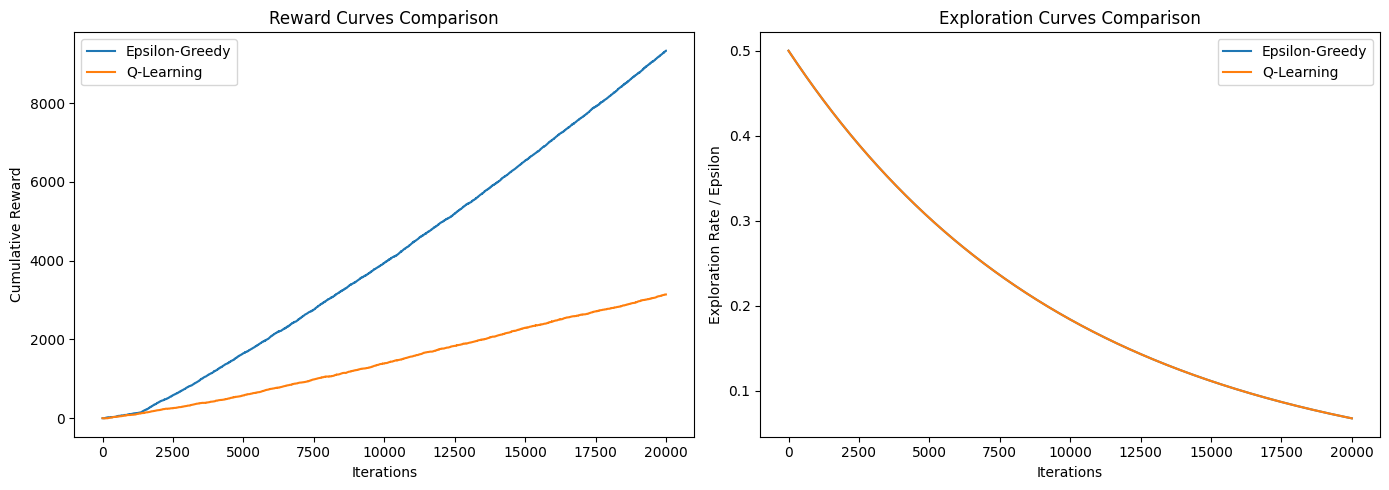

In [96]:
# ------------------------------
# Evaluation
# ------------------------------
def evaluate_all_recommenders(recommenders, n_iterations=20000, epsilon_start=0.5, epsilon_end=0.05, decay_rate=0.0001):
    """
    Evaluate multiple RL recommenders and plot reward/exploration curves for each.
    """
    results = {}

    for name, recommender in recommenders.items():
        total_reward = 0
        rewards = []
        exploration_rates = []

        sampled_users = ratings['user_id'].sample(n_iterations, replace=True).values

        for step in range(n_iterations):
            user_id = sampled_users[step]

            if hasattr(recommender, 'epsilon'):
                recommender.epsilon = max(epsilon_end, epsilon_start * np.exp(-decay_rate * step))

            recommended_movie = recommender.recommend(user_id)

            user_movie = ratings[(ratings['user_id'] == user_id) & (ratings['movie_id'] == recommended_movie)]
            if len(user_movie) > 0:
                reward = 1 if user_movie.iloc[0]['rating'] >= 4 else -1
            else:
                reward = 0

            if isinstance(recommender, QLearningRecommender):
                next_user_id = sampled_users[step+1] if step < n_iterations-1 else None
                recommender.update(user_id, recommended_movie, reward, next_user_id)
            else:
                recommender.update(recommended_movie, reward)

            total_reward += reward
            rewards.append(total_reward)
            exploration_rates.append(recommender.epsilon if hasattr(recommender, 'epsilon') else 0)

        results[name] = {
            'rewards': rewards,
            'exploration': exploration_rates,
            'final_reward': total_reward,
            'final_epsilon': exploration_rates[-1]
        }

        print(f"{name} -> Final Reward: {total_reward}, Final Epsilon: {exploration_rates[-1]:.4f}")

    plt.figure(figsize=(14,5))

    plt.subplot(1,2,1)
    for name, data in results.items():
        plt.plot(data['rewards'], label=name)
    plt.xlabel('Iterations')
    plt.ylabel('Cumulative Reward')
    plt.title('Reward Curves Comparison')
    plt.legend()

    plt.subplot(1,2,2)
    for name, data in results.items():
        plt.plot(data['exploration'], label=name)
    plt.xlabel('Iterations')
    plt.ylabel('Exploration Rate / Epsilon')
    plt.title('Exploration Curves Comparison')
    plt.legend()

    plt.tight_layout()
    plt.show()

recommenders = {
    "Epsilon-Greedy": EpsilonGreedyBandit(epsilon=0.5),
    "Q-Learning": QLearningRecommender(alpha=0.1, gamma=0.9, epsilon=0.5)
}

evaluate_all_recommenders(recommenders, n_iterations=20000)


In [97]:
# ------------------------------
# 3. Live feedback demo functions
# ------------------------------
epsilon_bandit = EpsilonGreedyBandit(epsilon=0.1)
ql_recommender = QLearningRecommender(alpha=0.1, gamma=0.9, epsilon=0.1)

def recommend_movie(user_id, method='bandit'):
    if method == 'bandit':
        recommended_movie = epsilon_bandit.recommend(user_id)
    elif method == 'qlearning':
        recommended_movie = ql_recommender.recommend(user_id)
    else:
        raise ValueError("method must be 'bandit' or 'qlearning'")
    movie_name = movies[movies['movie_id'] == movie_id]['title'].values[0]
    print(f"Recommended movie: {movie_name}")
    return recommended_movie

def user_feedback(movie_id, method='bandit'):
    feedback = int(input("Did you like the movie? (1 = Yes, 0 = No): "))
    reward = 1 if feedback == 1 else -1
    if method == 'bandit':
        epsilon_bandit.update(movie_id, reward)
    else:
        ql_recommender.update(user_id, movie_id, reward)

# ------------------------------
# Example interaction
# ------------------------------
user_id = 123
movie_id = recommend_movie(user_id, method='bandit')
user_feedback(movie_id, method='bandit')


Recommended movie: Bronx Tale, A (1993)
Did you like the movie? (1 = Yes, 0 = No): 1


In [105]:
def new_user_demo(ql_model):
    print("\nPick some favorite movies from the list:\n")
    sample = movies.sample(10)
    for _, row in sample.iterrows():
        print(f"{row.movie_id}: {row.title}")

    fav = input("\nEnter 1–5 movie IDs (comma separated): ")
    fav_ids = [int(x) for x in fav.split(",")]

    print("\n--- Top Recommendations ---")
    recommendations = ql_model.recommend_top_n_for_new_user(fav_ids, n=5)

    if not recommendations:
        print("No recommendations available.")
    else:
        for mid, title in recommendations:
            print(f"{mid}: {title}")


In [106]:
def get_user_preference_from_favorites(favorite_movie_ids):
    selected = movies[movies["movie_id"].isin(favorite_movie_ids)]

    if len(selected) == 0:
        return "new_user"

    genre_pref = selected[genre_columns].sum()
    top_genres = genre_pref.nlargest(2).index.tolist()

    if len(top_genres) == 0:
        return "new_user"

    return "_".join(top_genres)

In [109]:
# ------------------------------
# New User Recommendation
# ------------------------------
ql_model = recommenders["Q-Learning"]
new_user_demo(ql_model)


Pick some favorite movies from the list:

288: Scream (1996)
677: Fire on the Mountain (1996)
775: Something to Talk About (1995)
28: Apollo 13 (1995)
910: Nil By Mouth (1997)
589: Wild Bunch, The (1969)
774: Prophecy, The (1995)
715: To Die For (1995)
196: Dead Poets Society (1989)
443: Birds, The (1963)

Enter 1–5 movie IDs (comma separated): 288

--- Top Recommendations ---
980: Mother Night (1996)
1605: Love Serenade (1996)
841: Glimmer Man, The (1996)
172: Empire Strikes Back, The (1980)
1372: Stranger, The (1994)
